# PolyMath Benchmark Evaluation

Evaluate models on the [Qwen/PolyMath](https://huggingface.co/datasets/Qwen/PolyMath) benchmark with checkpointing support.
PolyMath is a multilingual math reasoning benchmark with 18 languages, 4 difficulty levels, and 500 problems per language.
Results are saved incrementally to `output_dir` so runs can be interrupted and resumed.

## Setup

In [1]:
import sys, os

# When running in Colab, clone the repo and add lib/ to the path
if "google.colab" in sys.modules:
    if not os.path.exists("cs224n-final-project"):
        !git clone https://github.com/anujjamwal/cs224n-final-project.git
    !cd cs224n-final-project && git checkout claude/math-eval-setup-cuuRV
    !cd cs224n-final-project && git pull
    sys.path.insert(0, "cs224n-final-project/lib")
    !pip install math-verify trl

    from google.colab import drive

    drive.mount('/content/drive')
    DATA_DIR="/content/drive/My Drive"

else:
    # Local: notebook lives inside lib/ already
    sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
    DATA_DIR="."

Mounted at /content/drive


In [2]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from eval import load_polymath, run_eval, summarize_results
from eval.runner import GenerationMode
from custom_generate.generate import _sample
from trainer import prepare_base_model

## Configuration

Edit the cell below to configure the evaluation.

In [10]:
# ---- Edit these ----
MODEL_PATH = "anujjamwal/OpenMath-Nemotron-1.5B-hcot"
MODEL_PATH = "nvidia/OpenMath-Nemotron-1.5B"
OUTPUT_DIR = os.path.join(DATA_DIR, "cs224n/eval/polymath-en-baseline")
BATCH_SIZE = 10
MAX_NEW_TOKENS = 4096
LANGUAGE = "en"      # Language config (e.g. "en", "zh", "fr", "de")
LEVELS = None        # e.g. ["top", "high"] to filter by difficulty
DTYPE = torch.bfloat16
NEEDS_PREPARE = False  # Set True if model needs special tokens added

## Load Model

In [ ]:
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, dtype=DTYPE, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

if NEEDS_PREPARE:
    model, tokenizer = prepare_base_model(model, tokenizer)

model.eval()
print(f"Model loaded: {MODEL_PATH} ({sum(p.numel() for p in model.parameters()) / 1e6:.0f}M params)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model loaded: nvidia/OpenMath-Nemotron-1.5B (1544M params)


In [5]:

# Generation modes to evaluate
MODES = [
    GenerationMode(name="Baseline", generate_fn=None, kwargs={}),
    # GenerationMode(name="Baseline", generate_fn=None, kwargs={"use_cache": True}),
]

## Load Dataset

In [6]:
problems = load_polymath(LANGUAGE, levels=LEVELS)
print(f"Loaded {len(problems)} PolyMath problems (language={LANGUAGE})")

# Preview
for p in problems[:3]:
    print(f"  [{p.id}] level={p.metadata['level']}")
    print(f"    {p.problem[:80]}...")
    print(f"    expected: {p.expected_answer}")

README.md: 0.00B [00:00, ?B/s]

en/top.parquet:   0%|          | 0.00/33.4k [00:00<?, ?B/s]

en/high.parquet:   0%|          | 0.00/29.1k [00:00<?, ?B/s]

en/medium.parquet:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

en/low.parquet:   0%|          | 0.00/22.6k [00:00<?, ?B/s]

Generating top split:   0%|          | 0/125 [00:00<?, ? examples/s]

Generating high split:   0%|          | 0/125 [00:00<?, ? examples/s]

Generating medium split:   0%|          | 0/125 [00:00<?, ? examples/s]

Generating low split:   0%|          | 0/125 [00:00<?, ? examples/s]

Loaded 500 PolyMath problems (language=en)
  [top-en-0] level=top
    Turbo the snail plays a game on a board with $2024$ rows and $2023$ columns. The...
    expected: 3
  [top-en-1] level=top
    Let $\mathbb{Q}$ be the set of rational numbers. A function $f: \mathbb{Q} \to \...
    expected: 2
  [top-en-2] level=top
    Let $n$ be a positive integer. A Japanese triangle consists of $1 + 2 + \dots + ...
    expected: $\lfloor \log_{2} n  \rfloor + 1$


## Run Evaluation

Results are checkpointed after each batch. If you interrupt and re-run this cell,
it will skip already-evaluated problems.

In [11]:
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(name)s: %(message)s")

results = run_eval(
    model, tokenizer, problems, OUTPUT_DIR, MODES,
    batch_size=BATCH_SIZE,
    max_new_tokens=MAX_NEW_TOKENS,
)

Eval [Baseline]:   0%|          | 0/50 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for

## Summary

In [12]:
import pandas as pd

summary = summarize_results(results)
print(f"Overall: {summary['correct']}/{summary['total']} ({summary['accuracy']:.1%})")
print()

# By mode
if summary.get("by_mode"):
    print("By mode:")
    for mode, stats in summary["by_mode"].items():
        print(f"  {mode}: {stats['correct']}/{stats['total']} ({stats['accuracy']:.1%})")
    print()

# By level (difficulty)
if summary.get("by_level"):
    print("By difficulty level:")
    level_order = ["top", "high", "medium", "low"]
    for level in level_order:
        if level in summary["by_level"]:
            stats = summary["by_level"][level]
            print(f"  {level}: {stats['correct']}/{stats['total']} ({stats['accuracy']:.1%})")

Overall: 92/500 (18.4%)

By mode:
  Baseline: 92/500 (18.4%)

By difficulty level:
  top: 0/125 (0.0%)
  high: 7/125 (5.6%)
  medium: 18/125 (14.4%)
  low: 67/125 (53.6%)


## Visualize

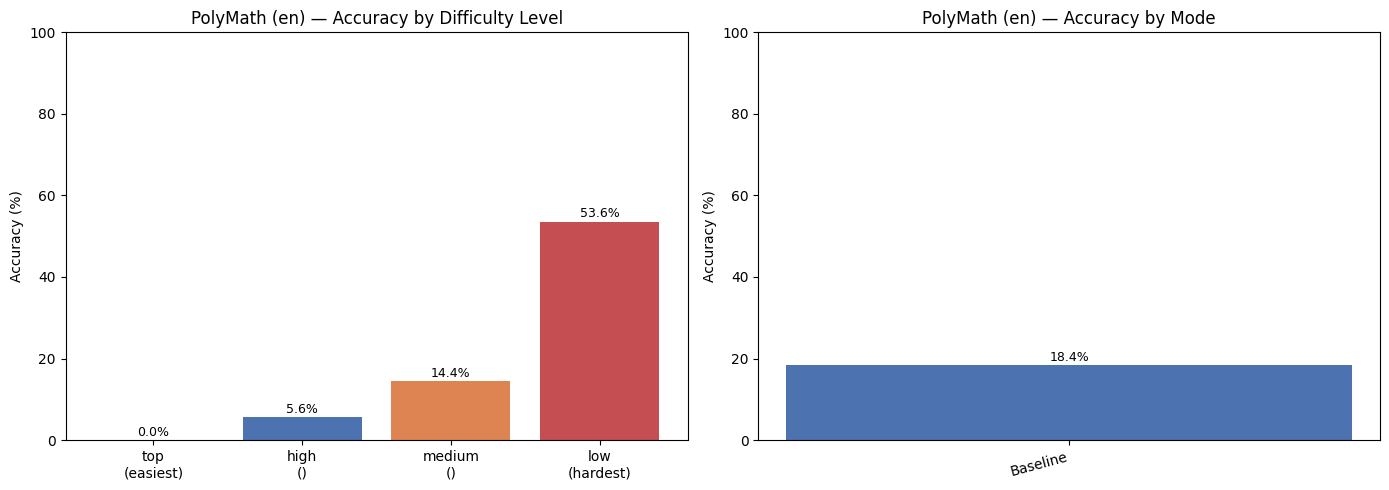

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy by difficulty level
if summary.get("by_level"):
    level_order = ["top", "high", "medium", "low"]
    levels = [l for l in level_order if l in summary["by_level"]]
    accs = [summary["by_level"][l]["accuracy"] * 100 for l in levels]
    labels = [f"{l}\n({'easiest' if l == 'top' else 'hardest' if l == 'low' else ''})" for l in levels]
    ax = axes[0]
    bars = ax.bar(labels, accs, color=["#55A868", "#4C72B0", "#DD8452", "#C44E52"])
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"PolyMath ({LANGUAGE}) — Accuracy by Difficulty Level")
    ax.set_ylim(0, 100)
    for bar, v in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

# Accuracy by mode
if summary.get("by_mode"):
    modes = list(summary["by_mode"].keys())
    accs = [summary["by_mode"][m]["accuracy"] * 100 for m in modes]
    ax = axes[1]
    bars = ax.bar(modes, accs, color=["#4C72B0", "#DD8452", "#55A868"][:len(modes)])
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"PolyMath ({LANGUAGE}) — Accuracy by Mode")
    ax.set_ylim(0, 100)
    for bar, v in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

plt.tight_layout()
plt.show()

## Inspect Individual Results

In [ ]:
# Load results as a DataFrame for exploration
df = pd.DataFrame([{
    "id": r.problem_id,
    "mode": r.mode,
    "correct": r.correct,
    "expected": r.expected,
    "predicted": r.predicted,
    "generated_tokens": r.generated_tokens,
    "wall_time": r.wall_time,
    "level": r.metadata.get("level"),
    "language": r.metadata.get("language"),
} for r in results])

print(f"Total results: {len(df)}")
print(f"\nIncorrect predictions (sample):")
display(df[~df["correct"]].head(10))

In [ ]:
df.to_json(os.path.join(OUTPUT_DIR, "polymath_output.json"), orient="records", lines=True)